# ML - Train test split

## Introduction

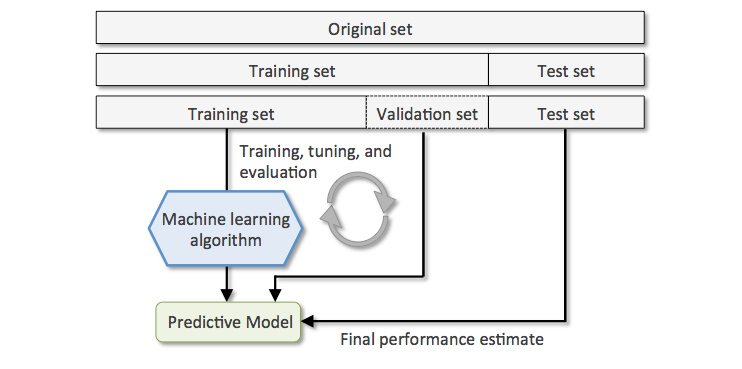

Comme vous le verrez, les jeux de données d'entrainement, de validation et de test sont très importants si vous voulez utiliser efficacement les algorithmes de Machine Learning. C'est assez simple, mais cela s'accompagne de certains concepts que vous apprendrez dans ce cours + challenge.

## Objectifs

✅ Comprendre la nécessité de diviser votre ensemble de données en jeu d'entrainement et en jeu de test.

✅ Comprendre les concepts d'overfitting et underfitting.

✅ Comprendre les limites du train-test split et la cross-validation

✅ Savoir interpréter des courbes d'apprentissage

## Overfitting et underfitting


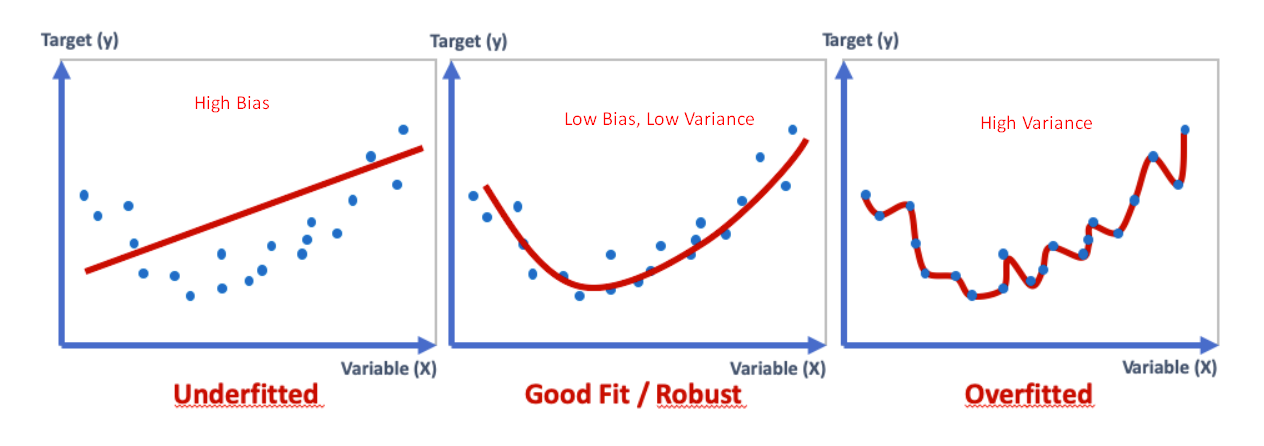
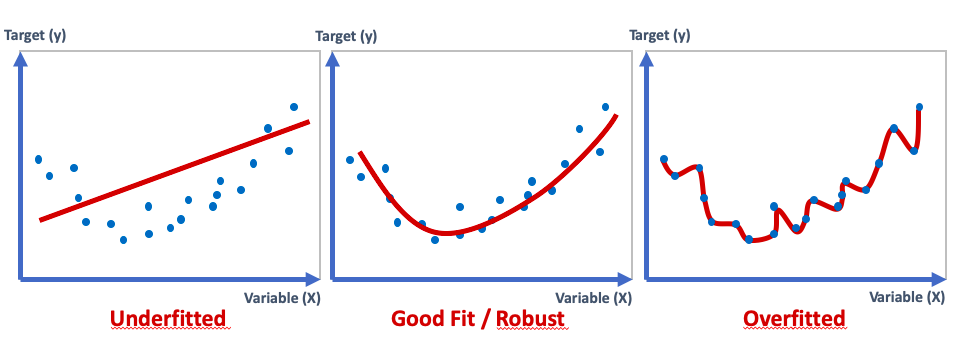

En apprentissage automatique, le **sur-ajustement** (overfitting ou high variance) se produit lorsqu'un modèle d'apprentissage est trop proche des données d'apprentissage. Cela conduit à un modèle trop complexe.

Le **sous-ajustement** (underfitting ou high bias) est le contraire. Il se produit lorsqu'un modèle d'apprentissage n'est pas assez complexe pour expliquer avec précision les relations entre les caractéristiques d'un ensemble de données et une variable cible donnée.

**Pour prédire de nouvelles valeurs, nous avons besoin d'un modèle bien ajusté.**

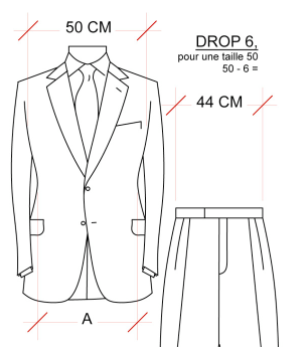

## Mais comment déterminer si notre modèle est bon ?


Nous utilisons des métriques ! Le score le plus connu pour les régressions est le **coefficient de détermination R2 (ou R au carré)**. *En statistique, le coefficient de détermination linéaire de Pearson, noté R2 ou r2, est une mesure de la qualité de la prédiction d'une régression linéaire.*

R2 = Variance expliquée / Variance totale.

Pour simplifier, le R2 mesure la différence entre les valeurs prédites et les valeurs réelles. Un bon score R2 signifie que nous minimisons la distance entre chaque valeur réelle et le modèle prédictif.

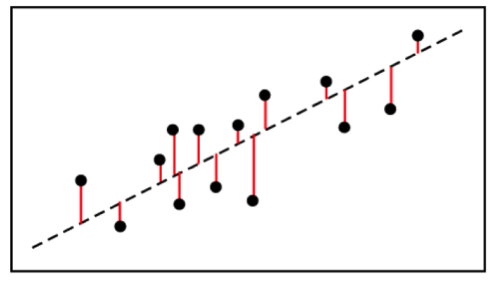

Le R-carré est toujours compris entre 0 et 1 :

- 0 indique que le modèle n'explique aucunement la variabilité des données de réponse autour de sa moyenne.
- 1 indique que le modèle explique parfaitement toute la variabilité des données de réponse.

Avec SciKit-Learn, il est très facile de scorer un modèle, il suffit d'utiliser la méthode `.score()`.



In [3]:
model.score(X,y)

NameError: name 'model' is not defined

Mais revenons à notre image précédente. Le modèle de droite (avec overfitting) aura probablement le meilleur score. Meilleur que le modèle du milieu. Parce que ce modèle avec overfitting explique parfaitement nos données. Cependant, nous pensons qu'il sera très mauvais pour faire des prédictions. **Donc le meilleur score est pour un mauvais modèle prédictif !** Comment pouvons-nous résoudre ce problème ?

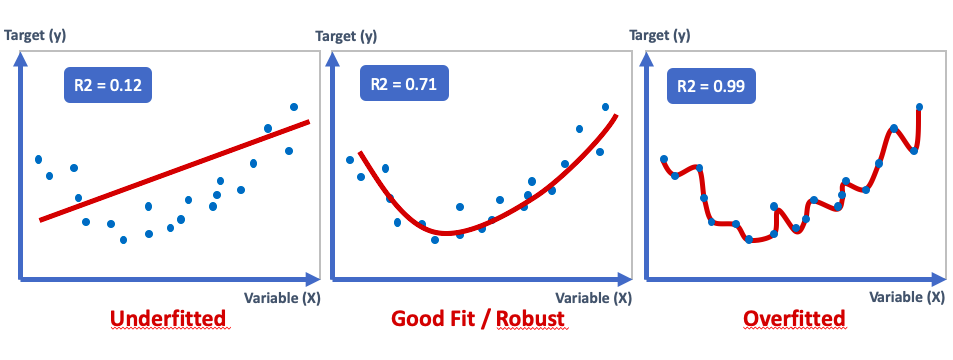

## Train Test Split ou "Holdout Method"


La solution à notre problème précédent est le Train Test Split !

1. Tout d'abord, nous divisons nos données en deux parties : un ensemble d'entraînement (souvent 75% ou 80% de notre ensemble de données initial) et un ensemble de test.
2. Ensuite, nous ajustons notre modèle uniquement sur l'ensemble d'entrainement. Notre modèle ne sait rien des données présentes dans l'ensemble de test.
3. Nous pouvons maintenant calculer le score sur l'ensemble de test. Pour notre modèle, il s'agit de nouvelles données. Et nous avons des valeurs réelles à comparer aux valeurs prédites.
4. Nous comparons notre score d'entrainement avec notre score de test. Si les deux sont à peu près identiques, il n'y a pas d'overfitting.

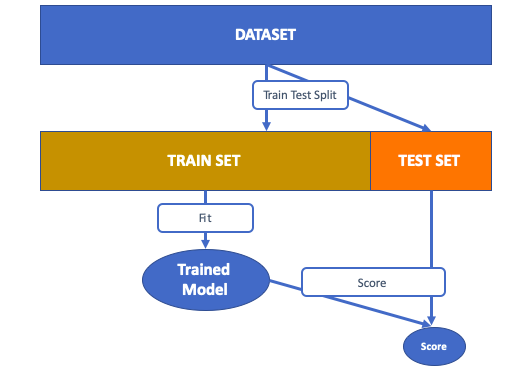

Nous devons donc trouver le meilleur mix entre :

- le meilleur score
- la plus petite distance entre le score d'entrainement et le score de test.

Ici, nous n'avons pas confiance dans le modèle surajusté, car il ne sait pas comment prédire de nouvelles valeurs.

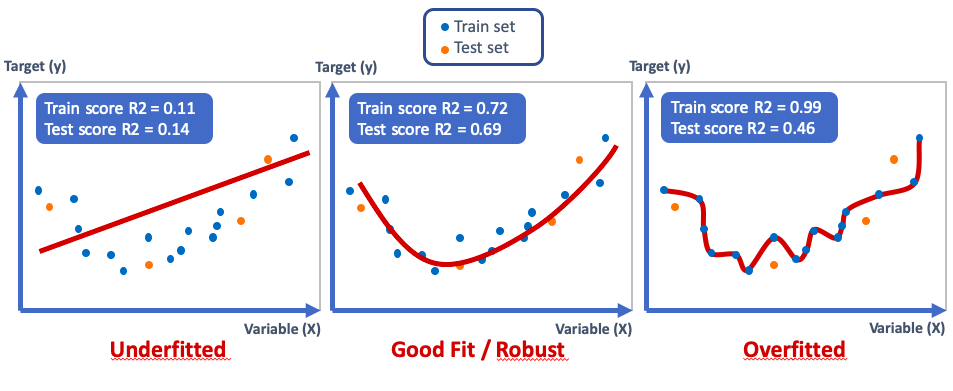

## avec Python et SciKit-Learn

Traditionnellement, vous divisez votre ensemble de données initial en :

- X : vos variables explicatives, avec une ou plusieurs colonnes.
- y : votre cible, avec une seule colonne.

Après la division train-test, vous obtiendrez 4 jeux de données :

- X_train : variables explicatives de l'ensemble train
- X_test : variables explicatives de l'ensemble de test
- y_train : cible de l'ensemble de formation
- y_test : cible de l'ensemble de test


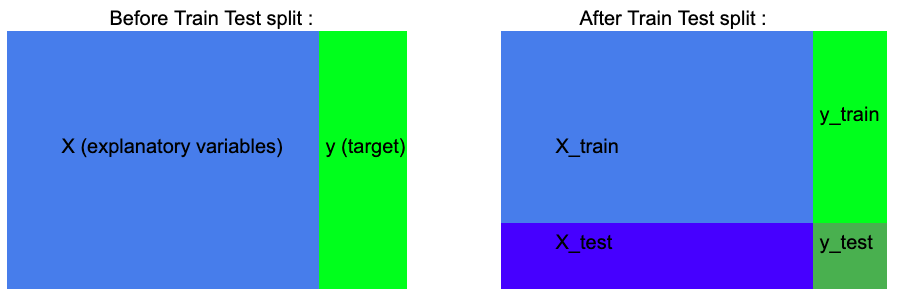

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.75)

### Shuffle

Pour être plus précis, par défaut, un Train Test Split commence par "randomiser" les lignes, c'est-à-dire les mettre dans un ordre aléatoire. Il ne prend pas les lignes dans l'ordre de l'ensemble de données. Vous comprendrez pourquoi dans le challenge. Cela ressemble donc plus à ceci :

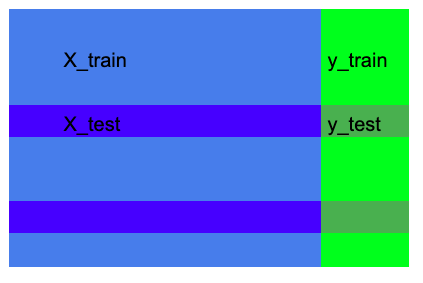

### Faisons une métaphore

Par exemple, si vous mémorisez chaque lettre du test des opticiens, vous pouvez obtenir un très bon score devant votre opticien... mais avez-vous une bonne vision ? Savez-vous bien lire ?

En Machine Learning, on appelle cela l'overfitting : un très bon score sur des données que la machine connait à l'avance. Mais vous ne pouvez pas généraliser à de nouvelles données (si le test de l'opticien change). Pour être sûr que la machine n'a pas mémorisé le résultat, nous utilisons la méthodologie Train Test Split.

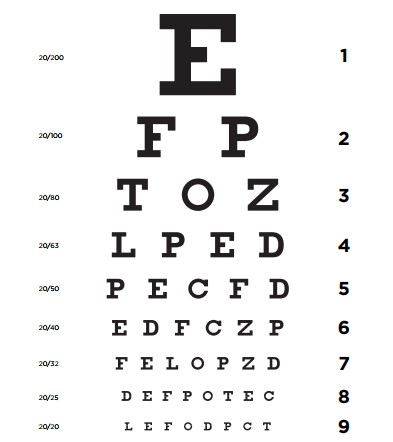

## Ensemble de validation

Pour information, les utilisateurs de l'apprentissage automatique divisent souvent les jeux de données en 3 parties et pas seulement en 2. Nous ne sommes qu'au début de l'apprentissage automatique. Commençons simplement. Nous n'utiliserons que le train set et le test set.

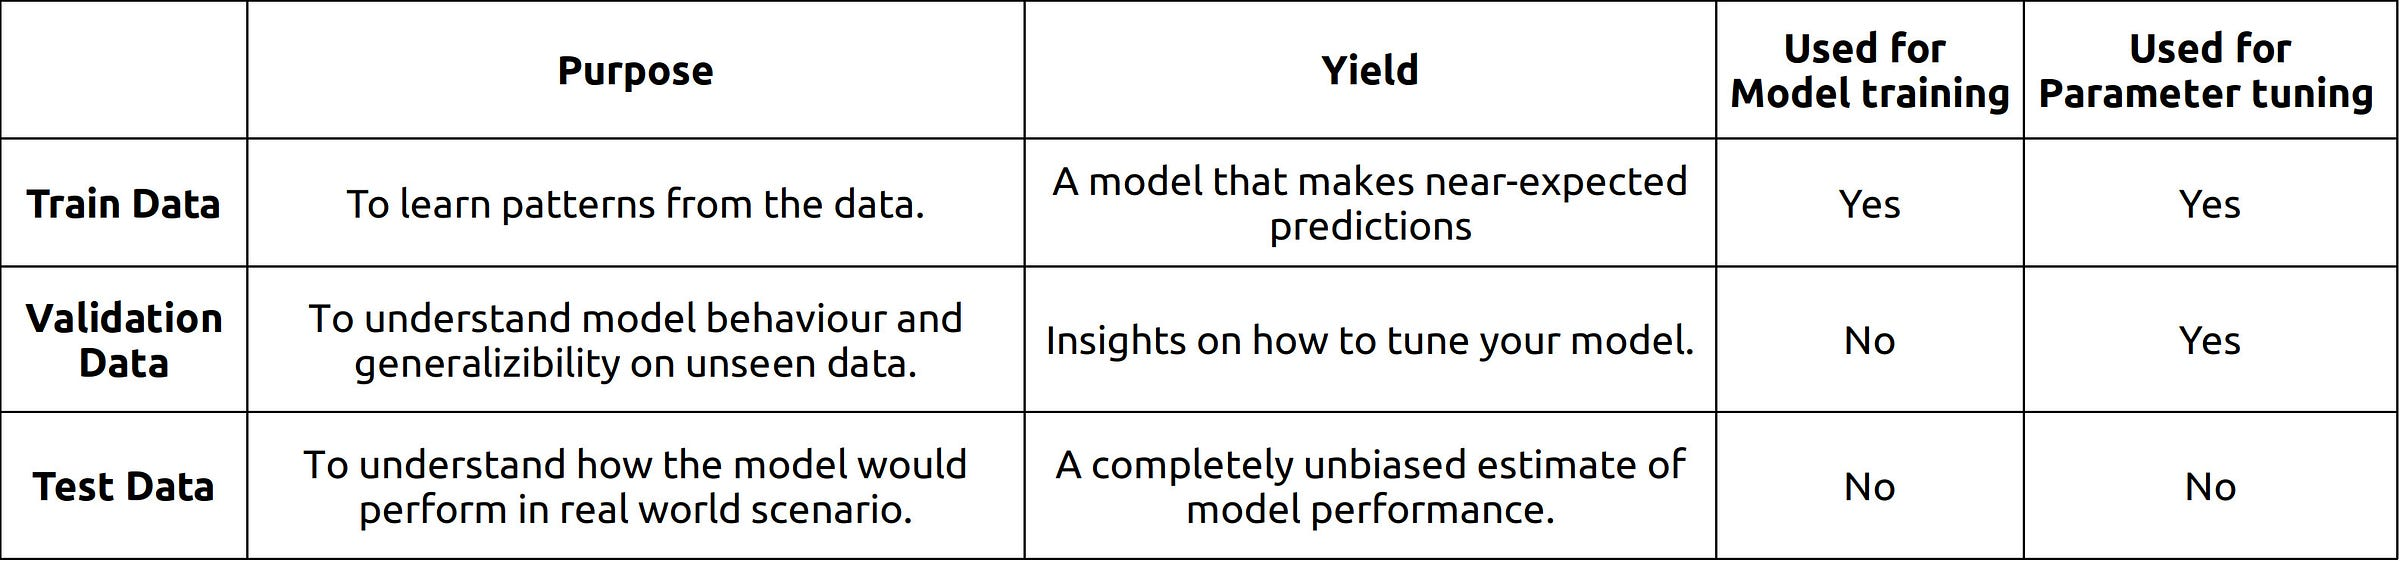

## Les limites du train test split


### La séparation est aléatoire.

>  Des splits différents créeront des résultats différents.

In [ ]:
### RUN THIS CELL MULTIPLE TIMES TO SEE DIFFERENT SCORES

# Split into Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate the model
model = LinearRegression()

# Train the model on the Training data
model.fit(X_train, y_train)

# Score the model on the Test data
model.score(X_test,y_test)

Il est posible d'utiliser l'option random_state, mais nous pouvons être facilement tentés d'en choisir un avec le meilleur score

### Perte d'information

> Les données dans le test set ne sont pas utilisées pour entraîner le modèle. Si vous avez un petit jeu de données, cette perte de données peut être un problème.

# La solution : K-Fold Cross Validation

1. Le jeu de données est divisé en un nombre de folds (plis) K.
2. Pour chaque division, un sous-modèle est entraîné et évalué.
3. La moyenne des scores de tous les sous-modèles est le **cross-validated** score du modèle (validé par croisement).

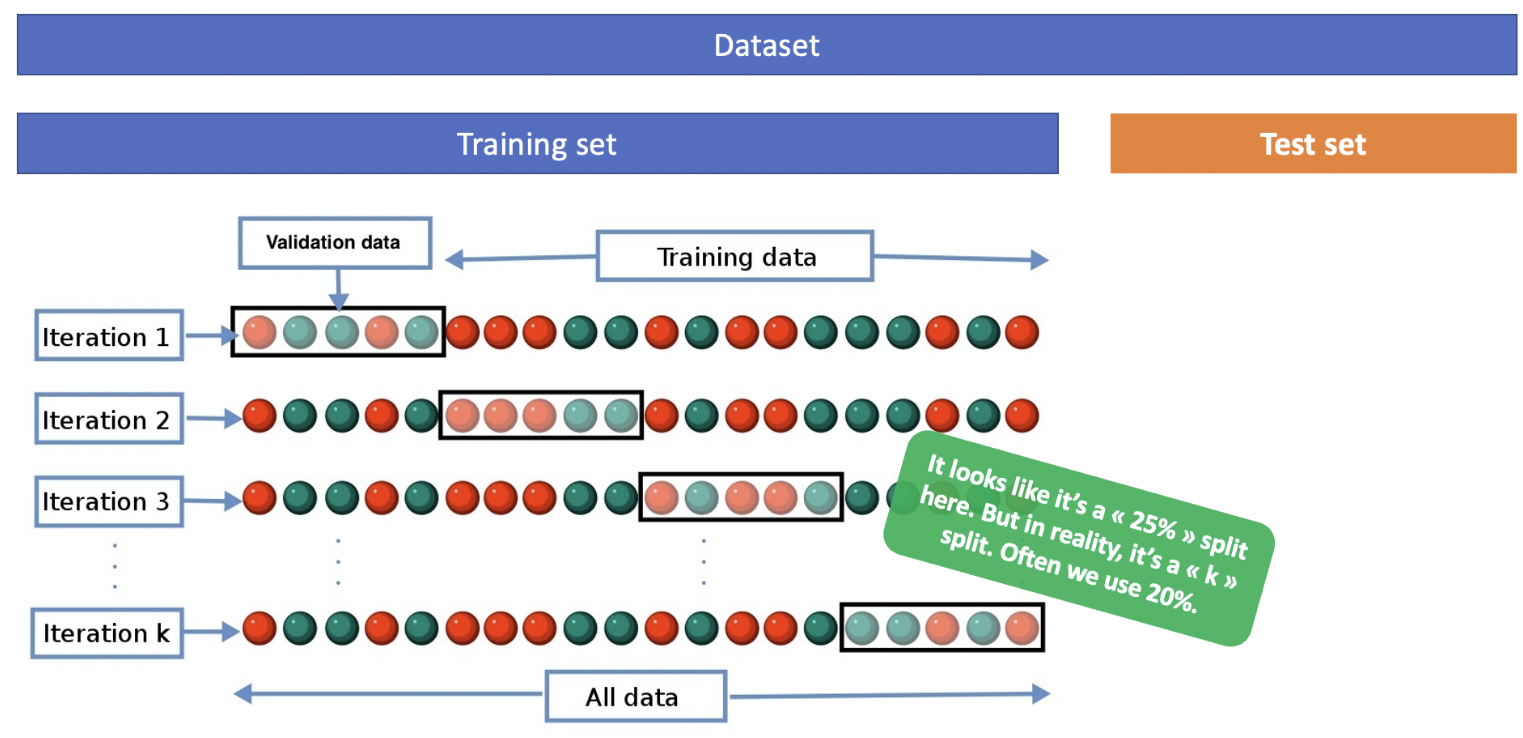

Autre exemple présentant les folds : 

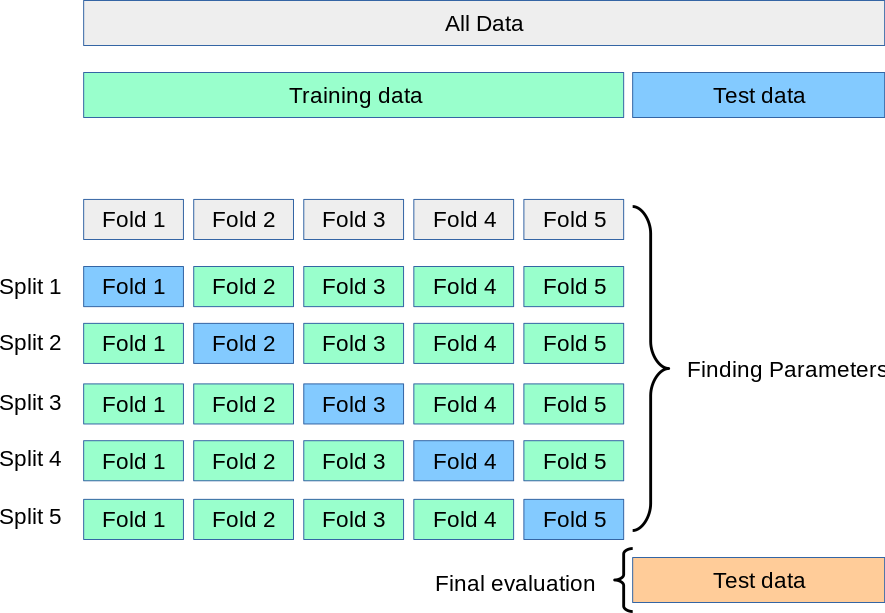

### Avec Sklearn

Exemple de [cross_validate](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html)

```python	
from sklearn.model_selection import cross_validate

# Instantiate model
model = LinearRegression()

# 5-Fold Cross validate model
cv_results = cross_validate(model, X, y, cv=5)

# Scores
print(cv_results['test_score'])

# Mean of scores
cv_results['test_score'].mean()

``` >>> [0.29966592 0.43383776 0.552854   0.59169285 0.51451021] ```

Exemple de [cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html#sklearn.model_selection.cross_val_score)

```python	
cross_val_score(KNeighborsClassifier(weights = 'distance'), 
                X, y, 
                cv = 3 )
```

```>>> array([0.76824324, 0.80878378, 0.76355932])```

Quelques remarques :

- La crossvalidation va devoir entrainer autant de modèles que de découpages, car à chaque fois, le jeu d'entrainement change.
- La crossvalidation va calculer autant de scores que de découpages, car à chaque fois, le jeu de test change.

**Par conséquent, nous fournissons directement `X` et `y` et non pas `X_train` et `y_train`, car c'est la crossvalidation qui fera les découpage successifs.**

- Nous devons lui fournir le modèle à entrainer.

- `cross_val_score` nous retourne un array d'une longueur égale au nombre de découpages (par défaut, 5)

- `cross_validate` nous retourne un dictionnaire contenant des arrays de longueur k (5 par défaut). Ces arrays contiennent multiples informations quant à la performance du modèle sur chaque découpage. Se référer à la [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html) pour plus d'informations.


- Plus il y a d'écart entre les valeurs, moins nous avons confiance dans la métrique (ca signifie que le découpage a beaucoup d'influence sur notre score). Nous pouvons calculer la moyenne de ces métriques qui sera alors un bon indicateur.

# Revenons en au "Bias Variance Tradeoff"

## Théorème "No Free Lunch"

Certains modèles *simplifient à l'excès*, tandis que d'autres *compliquent excessivement* la relation entre les caractéristiques et la cible.

En tant que scientifiques des données, il nous incombe de faire des *hypothèses* ou *assumptions* sur les données et d'évaluer les modèles raisonnables en conséquence.

Il n'existe pas de modèle universel qui convienne à tous les cas, c'est ce qu'on appelle le **[Théorème "No Free Lunch"](https://en.wikipedia.org/wiki/No_free_lunch_theorem)** (Théorème du "pas de solution miracle").

## Les Learning Curves ou Courbes d'apprentissage


Les courbes d'apprentissage sont utilisées pour diagnostiquer trois aspects du comportement du modèle sur le jeu de données :

* Underfitting / Sous-apprentissage : lorsque le modèle n'arrive pas à capturer les tendances des données
* Overfitting / Surapprentissage : lorsque le modèle apprend trop spécifiquement les données d'entraînement
* Si le modèle dispose de suffisamment de données : pour apprendre les motifs du jeu de données

## Concept

Increasing the size of the training set can affect the training and validation scores.

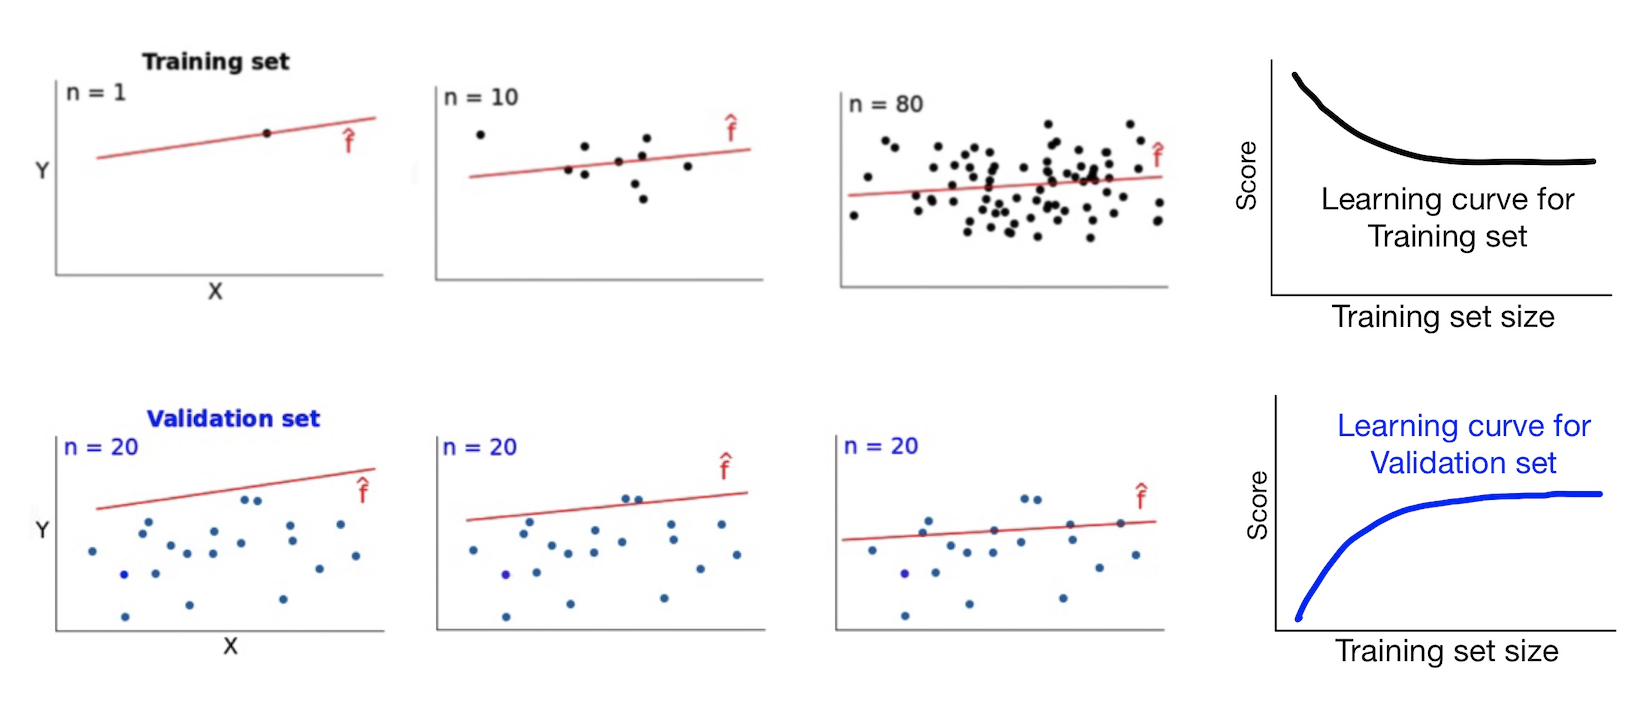

[Source](https://www.dataquest.io/blog/learning-curves-machine-learning/)

## Lire les courbes

Les deux courbes sont tracées ensemble sur le même graphique.
Au fur et à mesure que la taille de l'entraînement augmente:

* Training score / Score d'entraînement : diminuera 
* Test score / Score de test : augmentera 
* Les courbes démontrent typiquement (mais pas toujours !) une convergence

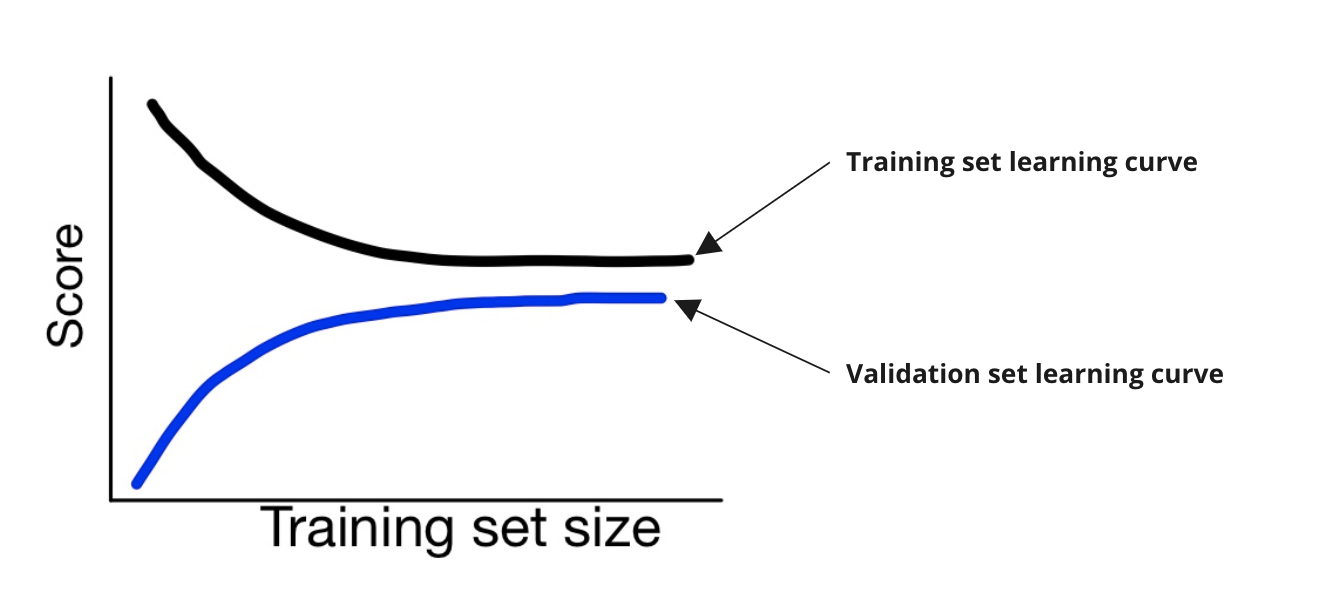

## Sous-apprentissage (Underfitting)

Scores faibles dans les **deux** jeux de données (training et test).

Si le modèle ne peut pas déterminer une relation dans le jeu d'entraînement, nous ne pouvons pas nous attendre à ce qu'il obtienne des scores élevés dans le jeu de test.

Les scores d'entraînement et de test convergent et **atteignent un plateau à un score faible** (they plateau at a low score). Peu importe la quantité de données utilisée pour l'entraînement, le modèle ne peut pas déterminer une relation significative.

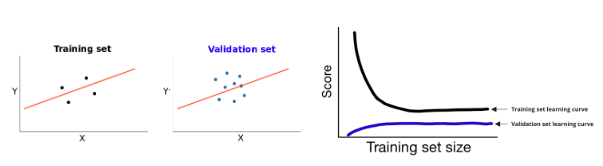

## Variance élevée (Overfitting)



Le modèle a accordé **trop d'attention** aux signaux et au bruit dans les données d'entraînement, conduisant à des **scores d'entraînement élevés**.

La **dépendance au bruit** ne se généralise pas bien sur les données non vues, entraînant des **scores de test faibles**. Plus de données d'entraînement *pourraient* aider dans ce cas.

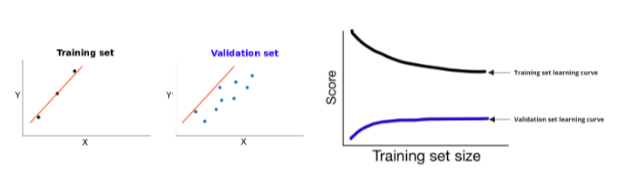

## Courbes idéales



* Score élevé sur le jeu d'entraînement
* Score élevé sur le jeu de test 
* Courbes convergentes 

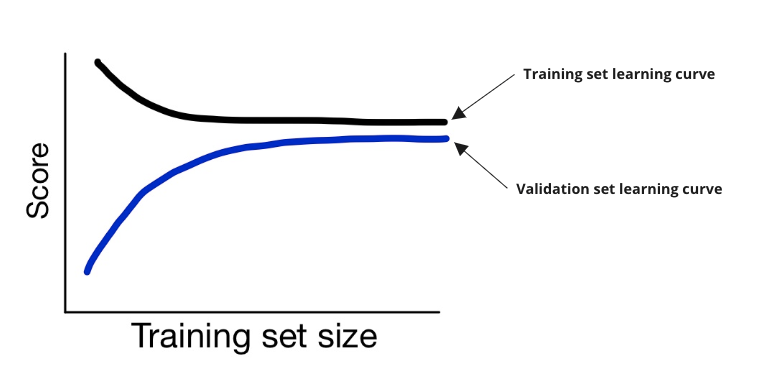

## Avec Scikit-learn

Traçons et analysons les courbes d'apprentissage (learning curves) d'un modèle de Régression sur les prix immobiliers.

[Doc learning_curve](learning_curve)

```python	
import numpy as np
from sklearn.model_selection import learning_curve

train_sizes = [25,50,75,100,250,500,750,1000,1150]

# Get train scores (R2), train sizes, and validation scores using `learning_curve`
train_sizes, train_scores, test_scores = learning_curve(
    estimator=LinearRegression(), X=X, y=y, train_sizes=train_sizes, cv=5)

# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# plt.plot(train_sizes, train_scores_mean, label = 'Training score')
# plt.plot(train_sizes, test_scores_mean, label = 'Test score')
# plt.ylabel('r2 score', fontsize = 14)
# plt.xlabel('Training set size', fontsize = 14)
# plt.title('Learning curves', fontsize = 18, y = 1.03)
# plt.legend()

```

## Lecture des courbes

👉 Les deux courbes ont convergé et atteint un plateau :

* Le modèle fait de son mieux pour identifier les patterns dans les données
* L'ajout de données supplémentaires n'améliorera pas ses performances

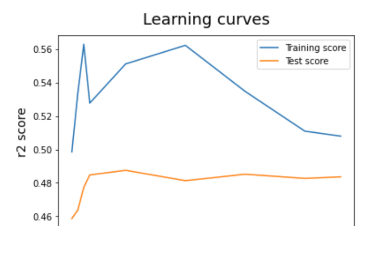


👉 Le score reste relativement faible (R² autour de 0,5) :

* C'est à nous d'essayer d'améliorer ce score tout en maintenant la capacité de généralisation.
* Vous apprendrez à le faire dans les exercices et lors des prochaines séances ! 💪

# Ressources pour aller plus loin :


Overfitting vs Underfitting : Un exemple complet

https://towardsdatascience.com/overfitting-vs-underfitting-a-complete-example-d05dd7e19765

Documentation Officielle Train Test Split Scikit-learn

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

User Guide sur la cross-validation dans Scikit-Learn

https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation

# Challenges

### Challenge : Train Test Split

Dans ce challenge, vous devrez accomplir une nouvelle série de missions pour apprendre à utiliser le train test split et à évaluer votre jeu de données.

Créez une copie de `Challenge ML - Train test split` et relevez le défi.

### Challenge : Learning Curves

Basculez ensuite vers le Challenge Learning Curves pour apprendre à utiliser la cross validation, les courbes d'apprentissage, et d'autres choses encore. Lisez le `README` pour comprendre le contexte du challenge.